# MAE ENCODER WITH VARIANCE BASED CLASSIFIER

# Imports

In [1]:
import sys
import shutil
from collections import Counter

import torch
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torch.nn as nn

from transformers import AutoImageProcessor, ViTImageProcessor, ViTMAEModel

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

import json
import os
import random
from tqdm.auto import tqdm



## Config

### Directories

In [2]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    # Configuration: Path to zip in Drive and extraction target
    # Assuming you uploaded Dataset.zip to AIgen_Image_Detection_Via_DL folder
    ZIP_SOURCE = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL/Dataset.zip"
    DATASET_ROOT = "/content/Dataset"

    if not os.path.exists(DATASET_ROOT):
        print("Copying zip from Drive to local runtime (faster unzipping)...")
        # Copy to local disk /content/ to avoid Drive I/O during unzip
        shutil.copy(ZIP_SOURCE, "/content/Dataset.zip")
        print("Unzipping dataset...")
        shutil.unpack_archive("/content/Dataset.zip", "/content/Dataset")
        print("Done!")
    else:
        print("Dataset already extracted.")
else:
    DEFAULT_ROOT = "E:/pigeon/Documents/ENSF617/AIgen_Image_Detection_Via_DL/Dataset"
    DATASET_ROOT = os.getenv("DATASET_ROOT", DEFAULT_ROOT)

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
TEST_DIR = os.path.join(DATASET_ROOT, "test")
VAL_DIR = os.path.join(DATASET_ROOT, "val")


Mounted at /content/drive
Copying zip from Drive to local runtime (faster unzipping)...
Unzipping dataset...
Done!


In [3]:
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    MODEL_ZIP = "/content/drive/MyDrive/AIgen_Image_Detection_Via_DL/myMAE.zip"
    MODEL_ROOT = "/content/myMAE"

    if not os.path.exists(MODEL_ROOT):
        print("Copying model zip to local runtime...")
        shutil.copy(MODEL_ZIP, "/content/myMAE.zip")

        print("Unzipping model...")
        shutil.unpack_archive("/content/myMAE.zip", "/content/myMAE")

        print("Model ready.")
    else:
        print("Model already extracted.")

else:
    MODEL_ROOT = "E:/pigeon/Documents/ENSF617/AIgen_Image_Detection_Via_DL/models/myMAE"

MODEL_DIR = os.getenv("MODEL_DIR", MODEL_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying model zip to local runtime...
Unzipping model...
Model ready.


### Hyperparameters

In [4]:
DATA_LOADER_BATCH_SIZE = 32
DATA_LOADER_NUM_WORKERS = 2

NUM_EPOCHS = 20
LEARNING_RATE = 3e-4

PATIENCE = 3

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

---

## Data Prepraration

In [82]:
# same processor as the one in MAE_on_FIDD.ipynb
# processor = AutoImageProcessor.from_pretrained("facebook/vit-mae-base")
processor = AutoImageProcessor.from_pretrained(MODEL_DIR)

In [83]:
# ViTMAE expects images normalized / resized via processor
def transform(image):
    return processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)

### Datasets & Data Loaders

In [84]:
# Datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=transform)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=transform)

In [85]:
# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=True, # only shuffle training data
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=DATA_LOADER_BATCH_SIZE,
    shuffle=False,
    num_workers=DATA_LOADER_NUM_WORKERS,
    persistent_workers=True,
    pin_memory=True
)

# Class mapping check
print("Classes:", train_dataset.classes)
print("Class to idx:", train_dataset.class_to_idx)

FAKE_LABEL = train_dataset.class_to_idx["Fake"]
REAL_LABEL = train_dataset.class_to_idx["Real"]

Classes: ['Fake', 'Real']
Class to idx: {'Fake': 0, 'Real': 1}


## Dataset Size Check

In [9]:
def get_class_counts(dataset):
    # ImageFolder stores labels in dataset.targets
    return Counter(dataset.targets)

train_counts = get_class_counts(train_dataset)
val_counts   = get_class_counts(val_dataset)
test_counts  = get_class_counts(test_dataset)

def map_counts(counts, dataset):
    idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
    return {
        idx_to_class[i]: counts.get(i, 0)
        for i in range(len(idx_to_class))
    }
print("\nTrain total:", sum(train_counts.values()))
print("Validation total:", sum(val_counts.values()))
print("Test total:", sum(test_counts.values()))

print("\nTrain class counts:", map_counts(train_counts, train_dataset))
print("Validation class counts:", map_counts(val_counts, val_dataset))
print("Test class counts:", map_counts(test_counts, test_dataset))


Train total: 2500
Validation total: 1182
Test total: 1250

Train class counts: {'Fake': 1000, 'Real': 1500}
Validation class counts: {'Fake': 432, 'Real': 750}
Test class counts: {'Fake': 500, 'Real': 750}


## Checking Device

In [10]:
if torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple GPU
    print("Using MPS (Apple GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # NVIDIA GPU
    print("Using CUDA")
else:
    device = torch.device("cpu")   # fallback
    print("Using CPU")

Using CUDA


---

## Model Definition
- Uses pretrained MAE (fine-tuned in MAE_on_FIDD.ipynb) as its encoder
- MLP classifier head

In [11]:
myMAE = ViTMAEModel.from_pretrained(MODEL_DIR)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: /content/myMAE
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.intermediate.dense.weight        | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.output.dense.bias      | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.weight   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.query.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.

In [20]:
class MAEVarianceClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        # Load the pretrained ViT-MAE model as the encoder
        self.encoder = myMAE
        # Freeze the encoder parameters to prevent training
        for param in self.encoder.parameters():
            param.requires_grad = False

        self.hidden_dim = self.encoder.config.hidden_size  # = 768 = the feature dimension

        # MLP head
        self.classifier = nn.Sequential(
          nn.LayerNorm(self.hidden_dim * 2),
          nn.Linear(self.hidden_dim * 2, 512),
          nn.GELU(),
          nn.Dropout(0.2),
          nn.Linear(512, 128),
          nn.GELU(),
          nn.Dropout(0.2),
          nn.Linear(128, num_classes)
        )

    def forward(self, pixel_values):
        outputs = self.encoder(pixel_values=pixel_values)

        patch_embeddings = outputs.last_hidden_state[:, 1:, :]  # remove CLS, keep only patch embeddings

        # compute variance across patch embeddings for each sample in the batch
        # measures how much each feature dimesion varies spatially
        var_vector = patch_embeddings.var(dim=1, unbiased=False)
        # measure overall feature level as well
        mean_vector = patch_embeddings.mean(dim=1)

        features = torch.cat([mean_vector, var_vector], dim=1)
        logits = self.classifier(features)

        return logits

### Model Initialization

In [21]:
model = MAEVarianceClassifier(num_classes=2) # Binary classification for now
model = model.to(device)

#### Verify encoder is frozen

In [22]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable_params}")
print(f"Total params: {total_params}")

Trainable params: 855938
Total params: 86654594


---
## Training

### Loss + Optimizer
- Only pass **classifier parameters** to optimizer since we do not want to train the encoder.
- This avoids accidentally trying to update the frozen encoder.

In [23]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=LEARNING_RATE
)

## Training Function

In [24]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # tqdm for progress tracking
    for images, labels in tqdm(dataloader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    acc = correct / total

    return avg_loss, acc

## Evaluation Function

In [25]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(dataloader), correct / total

---

## Main Training Loop

In [26]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}


best_val_loss = float("inf")
counter = 0

# Ensure encoder stays deterministic
model.encoder.eval()

# training loop with early stopping
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save best model
        torch.save(model.state_dict(), "best_variance_based_model.pt")
    else:
        counter += 1

        if counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break



Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.6416, Train Acc=0.6376, Val Loss=0.5580, Val Acc=0.7081


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.5362, Train Acc=0.7240, Val Loss=0.4580, Val Acc=0.8113


Training:   0%|          | 0/79 [00:00<?, ?it/s]

...

Epoch 18: Train Loss=0.1940, Train Acc=0.9204, Val Loss=0.2317, Val Acc=0.9129


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 19: Train Loss=0.2110, Train Acc=0.9128, Val Loss=0.2639, Val Acc=0.8968


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 20: Train Loss=0.1920, Train Acc=0.9232, Val Loss=0.2199, Val Acc=0.9120


### Plot training/validation curves
- Loss and Accuracy

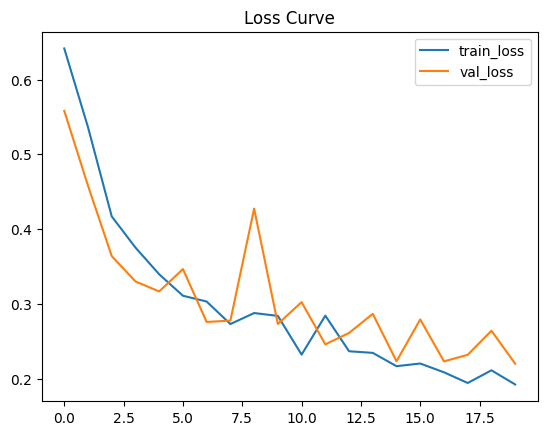

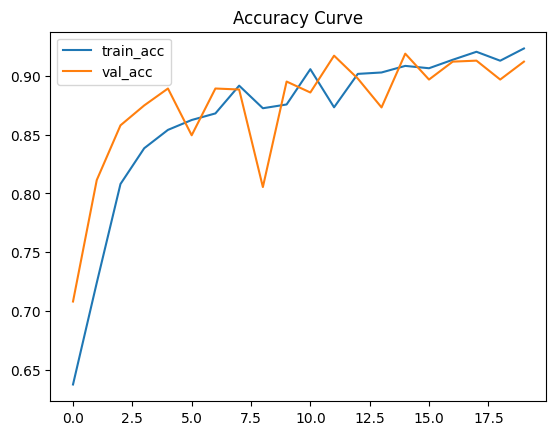

In [27]:
# Loss
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("loss_curve.png")
plt.show()

# Accuracy
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("accuracy_curve.png")
plt.show()

## Testing

In [ ]:
# load best model
model.load_state_dict(torch.load("best_variance_based_model.pt"))
model.eval()

# evaluate on test set
all_images = []
y_true = []
y_pred = []
y_prob = []
y_true_bin = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:, FAKE_LABEL]
        preds = (probs > 0.5).long()  # 1 = Fake, 0 = Real (Fake as the possitive class)

        all_images.append(images.cpu())
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

all_images = torch.cat(all_images, dim=0)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

y_true_bin = (y_true == FAKE_LABEL).astype(int) # treat fake as the positive class


### Compute Metrics

In [62]:
metrics = {
    "accuracy": accuracy_score(y_true_bin, y_pred),
    "precision": precision_score(y_true_bin, y_pred),
    "recall": recall_score(y_true_bin, y_pred),
    "f1_score": f1_score(y_true_bin, y_pred),
    "roc_auc": roc_auc_score(y_true_bin, y_prob)
}

print(metrics)

{'accuracy': 0.9128, 'precision': 0.9334811529933481, 'recall': 0.842, 'f1_score': 0.8853838065194533, 'roc_auc': np.float64(0.9787573333333333)}


### Save Metrics

In [63]:
with open("variance_based_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

## ROC Curve & Confusion Matrix

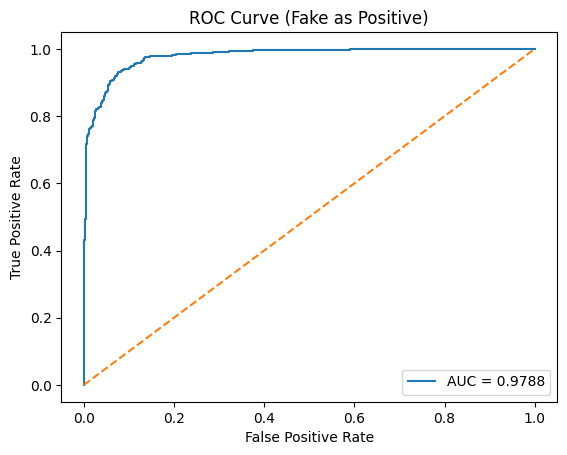

In [64]:
fpr, tpr, _ = roc_curve(y_true_bin, y_prob)  # Fake = positive
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Fake as Positive)")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

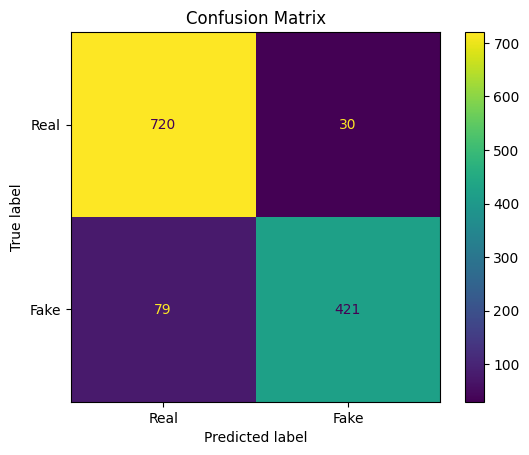

In [65]:
cm = confusion_matrix(y_true_bin, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real", "Fake"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

## Show Misclassified

In [66]:
real_as_fake_idx = np.where((y_true == REAL_LABEL) & (y_pred == 1))[0]
fake_as_real_idx = np.where((y_true == FAKE_LABEL) & (y_pred == 0))[0]

real_samples = real_as_fake_idx[:5]
fake_samples = fake_as_real_idx[:5]

real_probs = y_prob[real_samples]
fake_probs = y_prob[fake_samples]

In [76]:
# ImageNet denormalization (adjust if you used different mean/std)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denormalize(img):
    # img: HWC float or CHW torch tensor already converted to HWC numpy
    return img * IMAGENET_STD + IMAGENET_MEAN


def show_and_save_images(indices, probs, title, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    plt.figure(figsize=(12, 3))

    for i, idx in enumerate(indices):
        img = all_images[idx]

        # --- convert to numpy HWC ---
        if torch.is_tensor(img):
            img = img.detach().cpu()
            if img.ndim == 3:  # CHW -> HWC
                img = img.permute(1, 2, 0)
            img = img.numpy()

        elif isinstance(img, np.ndarray):
            if img.ndim == 3 and img.shape[0] in [1, 3]:  # CHW -> HWC
                img = np.transpose(img, (1, 2, 0))

        # --- ensure 3-channel RGB ---
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        elif img.shape[-1] == 1:
            img = np.repeat(img, 3, axis=-1)

        img = img.astype(np.float32)

        # --- DENORMALIZE ---
        img = denormalize(img)

        # --- clip only after denormalization ---
        img = np.clip(img, 0.0, 1.0)

        # --- SHOW ---
        plt.subplot(1, len(indices), i + 1)
        plt.imshow(img)
        plt.title(f"{probs[i]:.2f}")
        plt.axis('off')

        # --- SAVE ---
        filename = f"{title.replace(' ', '_')}_{i}_prob_{probs[i]:.3f}.png"
        path = os.path.join(save_dir, filename)
        plt.imsave(path, img)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

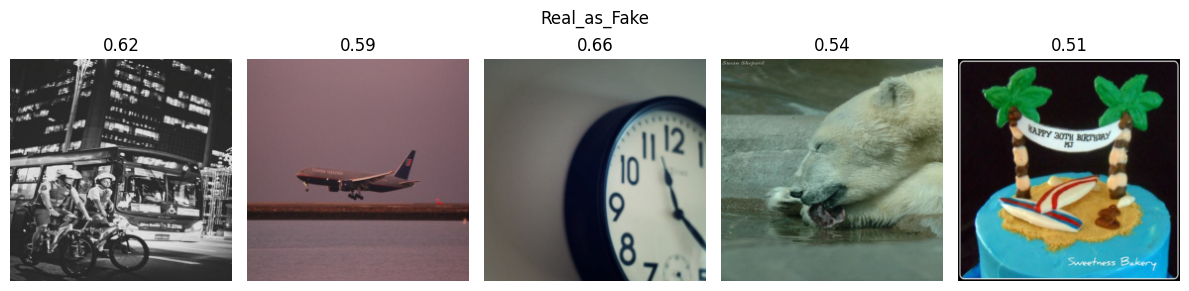

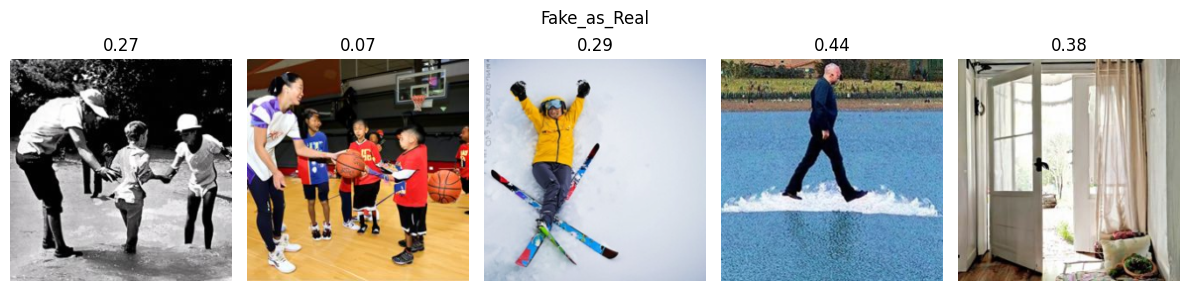

In [77]:
show_and_save_images(
    real_samples,
    real_probs,
    "Real_as_Fake",
    save_dir="outputs/real_as_fake"
)

show_and_save_images(
    fake_samples,
    fake_probs,
    "Fake_as_Real",
    save_dir="outputs/fake_as_real"
)

---
## Patch Variance/Mean Inspection
- only for data analysis

In [78]:
def extract_patch_stats_distribution(model, dataloader, device):
    model.eval()

    fake_vars, real_vars = [], []
    fake_means, real_means = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            patches = model.encoder(images).last_hidden_state  # (B, N, D)

            # remove CLS token if present
            patches = patches[:, 1:, :]  # safer for MAE/ViT

            # (B, D)
            var  = patches.var(dim=1, unbiased=False)
            mean = patches.mean(dim=1)

            # → scalar per image
            var  = var.mean(dim=1)
            mean = mean.mean(dim=1)

            var  = var.cpu().numpy()
            mean = mean.cpu().numpy()
            labels = labels.numpy()

            for v, m, y in zip(var, mean, labels):
                if y == 0:  # Fake
                    fake_vars.append(v)
                    fake_means.append(m)
                else:       # Real
                    real_vars.append(v)
                    real_means.append(m)

    return fake_vars, real_vars, fake_means, real_means

In [ ]:
# get per-image patch variance and mean
fake_vars_all = []
real_vars_all = []
fake_means_all = []
real_means_all = []

for loader in [train_loader, val_loader, test_loader]:
    fake_v, real_v, fake_m, real_m = extract_patch_stats_distribution(
        model, loader, device
    )

    fake_vars_all.extend(fake_v)
    real_vars_all.extend(real_v)

    fake_means_all.extend(fake_m)
    real_means_all.extend(real_m)

### Variance distribution

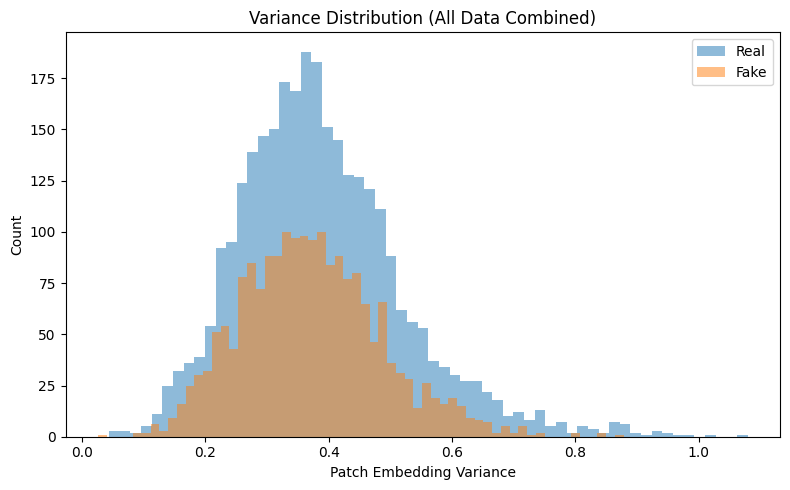

In [80]:
plt.figure(figsize=(8, 5))

plt.hist(real_vars_all, bins=60, alpha=0.5, label="Real")
plt.hist(fake_vars_all, bins=60, alpha=0.5, label="Fake")

plt.xlabel("Patch Embedding Variance")
plt.ylabel("Count")
plt.title("Variance Distribution (All Data Combined)")
plt.legend()

plt.tight_layout()
plt.savefig("variance_distribution.png")
plt.show()

### Mean distribution

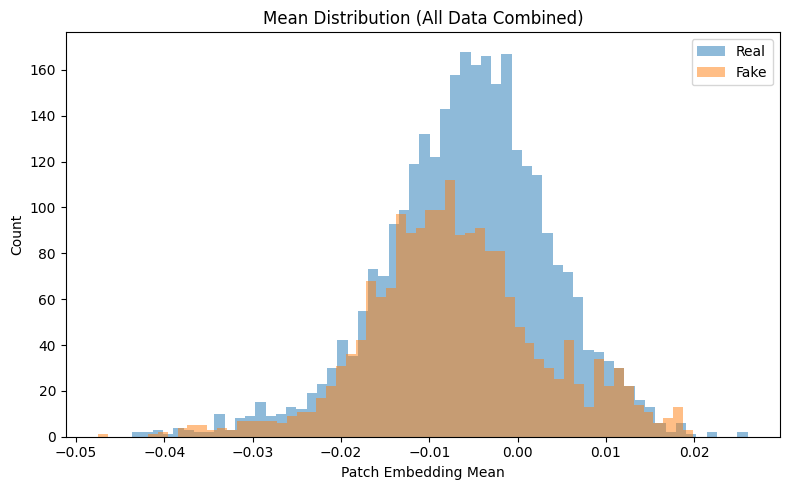

In [81]:
plt.figure(figsize=(8, 5))

plt.hist(real_means_all, bins=60, alpha=0.5, label="Real")
plt.hist(fake_means_all, bins=60, alpha=0.5, label="Fake")

plt.xlabel("Patch Embedding Mean")
plt.ylabel("Count")
plt.title("Mean Distribution (All Data Combined)")
plt.legend()

plt.tight_layout()
plt.savefig("mean_distribution.png")
plt.show()